In [1]:
import requests, json
import pandas as pd

In [2]:
headers = {
    'User-Agent': 'Mozilla',
    'X-Requested-With': 'XMLHttpRequest',
}

In [3]:
acct_is = {
    'Revenue': '매출액', 
    'Cost of Revenue': '매출원가', 
    'Gross Profit': '매출총이익', 
    'SG&A Expenses': '판매비와관리비',
    'Operating Income': '영업이익', 
    'Net Income Common': '당기순이익',
    'EPS (Basic)': 'EPS', 
    'EBITDA': 'EBITDA', 
    'EBIT': 'EBIT', 
    }

In [4]:
acct_bs = {
    'Total current assets': '유동자산', 
    'Total non-current assets': '비유동자산', 
    'Total Assets': '자산', 
    'Total current liabilities': '유동부채',
    'Long Term Debt (Total)': '장기차입금', 
    'Total non-current liabilities': '비유동부채',
    'Total liabilities': '부채', 
    'Shareholders Equity (Total)': '자본', 
    'Shares (Common)': '발행주식수', 
    }

In [5]:
acct_cf = {
    'Operating Cash Flow': '영업활동현금흐름', 
    'Investing cash flow': '투자활동현금흐름', 
    'Financing cash flow': '재무활동현금흐름', 
    'Dividends Paid (Total)': '배당금지급', 
    }

In [6]:
acct_ra = {
    'ROE': 'ROE', 
    'ROA': 'ROA', 
    'ROIC': 'ROIC', 
    'P/E ratio': 'PER', 
    'P/S ratio': 'PSR',
    'P/FCF ratio': 'P/FCF',
    'P/B ratio': 'PBR',
    'EV/Sales': 'EV/Sales',
    'EV/EBITDA': 'EV/EBITDA',
    'Enterprise Value': 'EV',
    'Market Cap': '시가총액',
    'Quick Ratio': '당좌비율',
    'Current Ratio': '유동비율',
    'Debt/Equity': 'Debt/Equity',
    'Debt/Assets': '부채비율',
    'Asset Turnover': '총자산회전율',
    'Dividend Yield': '배당수익률',
    'Earnings Yield': '영업이익률',
    'Free Cash Flow': '잉여현금흐름',
    }

In [7]:
indicator_url = 'https://stockrow.com/api/indicators.json'
r = requests.get(indicator_url, headers=headers)
indicators = json.loads(r.text)

In [8]:
df_indicator = pd.read_json(r.text, orient='records')
df_indicator.set_index('id', inplace=True)

In [9]:
df_indicator.query('name=="{}"'.format('EPS (Basic, Consolidated)'))

,name,code,dimension,unit,position,bold,italic,border,offset,keywords,group,chartable,description,verbose_dimension
id,,,,,,,,,,,,,,
7eee0e18-4e60-4ac6-82df-9f22616a102a,"EPS (Basic, Consolidated)",EPSBCONS,Q,cash ratio,38,False,False,False,0,,Per share,1.0,,(quarterly)
1053b26c-59e4-4ac7-8f36-04968304b70c,"EPS (Basic, Consolidated)",EPSBCONS,T,cash ratio,34,False,False,False,0,,Per share,1.0,,(trailing annual)
e526f384-0e3b-4817-8eee-99891b9b38af,"EPS (Basic, Consolidated)",EPSBCONS,A,cash ratio,37,False,False,False,0,,Per share,1.0,,(annual)


In [10]:
df_indicator.loc[(df_indicator.name=='{}'.format('EPS (Basic, Consolidated)')), 'k_name'] = 'EPS'

In [11]:
for k, v in acct_is.items():
    df_indicator.loc[(df_indicator.name=='{}'.format(k)), 'k_name'] = v
for k, v in acct_bs.items():
    df_indicator.loc[(df_indicator.name=='{}'.format(k)), 'k_name'] = v
for k, v in acct_cf.items():
    df_indicator.loc[(df_indicator.name=='{}'.format(k)), 'k_name'] = v
for k, v in acct_ra.items():
    df_indicator.loc[(df_indicator.name=='{}'.format(k)), 'k_name'] = v

In [12]:
df_indicator[ (df_indicator['name']=='{}'.format('EPS (Basic, Consolidated)')) 
    & (df_indicator['verbose_dimension']=='{}'.format('(trailing annual)')) ]

,name,code,dimension,unit,position,bold,italic,border,offset,keywords,group,chartable,description,verbose_dimension,k_name
id,,,,,,,,,,,,,,,
1053b26c-59e4-4ac7-8f36-04968304b70c,"EPS (Basic, Consolidated)",EPSBCONS,T,cash ratio,34,False,False,False,0,,Per share,1.0,,(trailing annual),EPS


In [13]:
def stockrow_ttm(symbol):
    url = 'https://stockrow.com/api/companies/{s}/financials.json?ticker={s}&dimension=T&section=Income+Statement'.format(s=symbol)
    r = requests.get(url, headers=headers)
    df_is = pd.read_json(r.text, orient='records')
    df_is.set_index('id', inplace=True)
    url = 'https://stockrow.com/api/companies/{s}/financials.json?ticker={s}&dimension=Q&section=Balance+Sheet'.format(s=symbol)
    r = requests.get(url, headers=headers)
    df_bs = pd.read_json(r.text, orient='records')
    df_bs.set_index('id', inplace=True)
    url = 'https://stockrow.com/api/companies/{s}/financials.json?ticker={s}&dimension=T&section=Cash+Flow'.format(s=symbol)
    r = requests.get(url, headers=headers)
    df_cf = pd.read_json(r.text, orient='records')
    df_cf.set_index('id', inplace=True)
    url = 'https://stockrow.com/api/companies/{s}/financials.json?ticker={s}&dimension=T&section=Metrics'.format(s=symbol)
    r = requests.get(url, headers=headers)
    df_rm = pd.read_json(r.text, orient='records')
    df_rm.set_index('id', inplace=True)
    url = 'https://stockrow.com/api/companies/{s}/financials.json?ticker={s}&dimension=Q&section=Metrics'.format(s=symbol)
    r = requests.get(url, headers=headers)
    df_ra = pd.read_json(r.text, orient='records')
    df_ra.set_index('id', inplace=True)
    df = pd.concat([df_is, df_bs, df_cf, df_rm, df_ra], axis=0)
    return df

In [14]:
symbol = 'AAPL'
stmt = stockrow_ttm(symbol)

In [15]:
def fn_account(stmt, df_indicator, account='Revenue', dimension='T'):
    i = df_indicator[ (df_indicator['name']==account) & (df_indicator['dimension']==dimension) ].index[0]
    acct = stmt.loc[i]
    acct.name = account
    return acct

In [16]:
def fn_account(stmt, df_indicator, account=['Revenue'], dimension='T'):
    id = []
    for a in account:
        try:
            id.append(df_indicator[ (df_indicator['name']==a) & (df_indicator['dimension']==dimension) ].index[0])
        except:
            pass
    rst = stmt.loc[id]
    converter = {}
    for i in range(len(id)):
        converter[id[i]] = df_indicator.k_name.loc[id[i]]
    return rst.rename(index=converter)

In [17]:
fn_is_t = fn_account(stmt, df_indicator, account=list(acct_is.keys()), dimension='T')

In [18]:
fn_cf_t = fn_account(stmt, df_indicator, account=list(acct_cf.keys()), dimension='T')

In [19]:
fn_bs_q = fn_account(stmt, df_indicator, account=list(acct_bs.keys()), dimension='Q')

In [20]:
fn_ra_q = fn_account(stmt, df_indicator, account=list(acct_ra.keys()), dimension='Q')

In [21]:
fn_ra_t = fn_account(stmt, df_indicator, account=list(acct_ra.keys()), dimension='T')

In [22]:
fn = pd.concat([fn_is_t, fn_cf_t, fn_bs_q, fn_ra_q, fn_ra_t], axis=0).T
fn.index = pd.to_datetime(fn.index)

In [23]:
fn.head()

id,매출액,매출원가,매출총이익,판매비와관리비,영업이익,당기순이익,EPS,EBITDA,EBIT,영업활동현금흐름,투자활동현금흐름,재무활동현금흐름,배당금지급,유동자산,비유동자산,자산,유동부채,장기차입금,비유동부채,부채,자본,발행주식수,PER,PSR,P/FCF,PBR,EV/Sales,EV/EBITDA,EV,시가총액,당좌비율,유동비율,Debt/Equity,부채비율,총자산회전율,배당수익률,영업이익률,잉여현금흐름,ROE,ROA,ROIC,잉여현금흐름
2020-09-30,2.745150e+11,1.695590e+11,1.049560e+11,1.991600e+10,6.628800e+10,5.741100e+10,3.2975,7.734400e+10,6.628800e+10,8.067400e+10,-4.289000e+09,-8.682000e+10,-1.408100e+10,1.437130e+11,1.801750e+11,3.238880e+11,1.053920e+11,9.866700e+10,1.531570e+11,2.585490e+11,6.533900e+10,1.697676e+10,35.1205,7.3204,27.3870,30.7557,7.3987,26.2599,2.031042e+12,2.009549e+12,1.2182,1.3636,1.7208,0.3471,0.8288,0.0070,0.0285,1.879200e+10,0.7369,0.1733,0.4771,7.336500e+10
2020-06-30,2.738570e+11,1.692770e+11,1.045800e+11,1.955800e+10,6.713800e+10,5.842400e+10,3.3200,7.867100e+10,6.713800e+10,8.000800e+10,-1.061800e+10,-8.650200e+10,-1.404900e+10,1.400650e+11,1.772790e+11,3.173440e+11,9.531800e+10,9.404800e+10,1.497440e+11,2.450620e+11,7.228200e+10,1.713576e+10,27.4699,5.7447,21.9366,21.7651,5.8166,20.2479,1.592924e+12,1.573226e+12,1.3124,1.4694,1.5595,0.3552,0.8564,0.0089,0.0364,1.470600e+10,0.6925,0.1827,0.4562,7.170600e+10
2020-03-31,2.679810e+11,1.658540e+11,1.021270e+11,1.915300e+10,6.559100e+10,5.721500e+10,3.2175,7.730500e+10,6.559100e+10,7.537300e+10,2.204900e+10,-9.419000e+10,-1.402200e+10,1.437530e+11,1.766470e+11,3.204000e+11,9.609400e+10,8.908600e+10,1.458810e+11,2.419750e+11,7.842500e+10,1.729595e+10,19.7584,4.1373,16.6359,14.1375,4.1950,14.5422,1.124186e+12,1.108730e+12,1.2980,1.4960,1.3963,0.3418,0.8091,0.0126,0.0506,1.145800e+10,0.6209,0.1728,0.4367,6.663600e+10
2019-12-31,2.676830e+11,1.661050e+11,1.015780e+11,1.865900e+10,6.615300e+10,5.752700e+10,3.1900,7.812100e+10,6.615300e+10,7.321700e+10,2.638400e+10,-1.027070e+11,-1.409000e+10,1.632310e+11,1.773870e+11,3.406180e+11,1.021610e+11,9.307800e+10,1.489260e+11,2.510870e+11,8.953100e+10,1.753984e+10,23.0133,4.8433,20.2635,14.4808,4.8475,16.6102,1.297606e+12,1.296476e+12,1.4400,1.5978,1.2095,0.3179,0.7495,0.0109,0.0435,2.840900e+10,0.5547,0.1611,0.4560,6.397000e+10
2019-09-30,2.601740e+11,1.617820e+11,9.839200e+10,1.824500e+10,6.393000e+10,5.525600e+10,2.9850,7.647700e+10,6.393000e+10,6.939100e+10,4.589600e+10,-9.097600e+10,-1.411900e+10,1.628190e+11,1.756970e+11,3.385160e+11,1.057180e+11,9.180700e+10,1.423100e+11,2.480280e+11,9.048800e+10,1.777295e+10,18.7580,3.9752,17.5574,11.4298,4.0040,13.6217,1.041747e+12,1.034257e+12,1.3844,1.5401,1.1940,0.3192,0.7389,0.0137,0.0533,1.713300e+10,0.5592,0.1569,0.4078,5.889600e+10


가격 부분

In [24]:
price_url = 'https://stockrow.com/api/fundamentals.json'
payloads = {
    'indicators': '99294e26-cf6f-45d8-8a6c-c7649b8579e2',
    'tickers': symbol
}
r = requests.post(price_url, data=payloads, headers=headers)


In [25]:
data = json.loads(r.text)
prices = data['series'][0]['data']
prices[-2]

[1606780800000, 121.01, 123.47, 120.01, 122.72, 127728200.0]

In [26]:
price_dict = {}
for p in prices:
    price_dict[pd.to_datetime(p[0], unit='ms').date()] = p[4]
price_dict[pd.to_datetime(prices[-1][0], unit='ms').date()]

123.08

In [27]:
pd.to_datetime(prices[0][0], unit='ms').date()

datetime.date(2011, 1, 3)

In [28]:
price_df = pd.DataFrame.from_dict(price_dict, orient='index', columns=['Price'])
price_df.index = pd.to_datetime(price_df.index)
price_df.tail()

,Price
2020-11-25,116.03
2020-11-27,116.59
2020-11-30,119.05
2020-12-01,122.72
2020-12-02,123.08


In [29]:
df = pd.concat([fn, price_df], axis=1)
df.fillna(method='ffill', inplace=True)
df.tail()

,매출액,매출원가,매출총이익,판매비와관리비,영업이익,당기순이익,EPS,EBITDA,EBIT,영업활동현금흐름,투자활동현금흐름,재무활동현금흐름,배당금지급,유동자산,비유동자산,자산,유동부채,장기차입금,비유동부채,부채,자본,발행주식수,PER,PSR,P/FCF,PBR,EV/Sales,EV/EBITDA,EV,시가총액,당좌비율,유동비율,Debt/Equity,부채비율,총자산회전율,배당수익률,영업이익률,잉여현금흐름,ROE,ROA,ROIC,잉여현금흐름,Price
2020-11-25,2.745150e+11,1.695590e+11,1.049560e+11,1.991600e+10,6.628800e+10,5.741100e+10,3.2975,7.734400e+10,6.628800e+10,8.067400e+10,-4.289000e+09,-8.682000e+10,-1.408100e+10,1.437130e+11,1.801750e+11,3.238880e+11,1.053920e+11,9.866700e+10,1.531570e+11,2.585490e+11,6.533900e+10,1.697676e+10,35.1205,7.3204,27.387,30.7557,7.3987,26.2599,2.031042e+12,2.009549e+12,1.2182,1.3636,1.7208,0.3471,0.8288,0.007,0.0285,1.879200e+10,0.7369,0.1733,0.4771,7.336500e+10,116.03
2020-11-27,2.745150e+11,1.695590e+11,1.049560e+11,1.991600e+10,6.628800e+10,5.741100e+10,3.2975,7.734400e+10,6.628800e+10,8.067400e+10,-4.289000e+09,-8.682000e+10,-1.408100e+10,1.437130e+11,1.801750e+11,3.238880e+11,1.053920e+11,9.866700e+10,1.531570e+11,2.585490e+11,6.533900e+10,1.697676e+10,35.1205,7.3204,27.387,30.7557,7.3987,26.2599,2.031042e+12,2.009549e+12,1.2182,1.3636,1.7208,0.3471,0.8288,0.007,0.0285,1.879200e+10,0.7369,0.1733,0.4771,7.336500e+10,116.59
2020-11-30,2.745150e+11,1.695590e+11,1.049560e+11,1.991600e+10,6.628800e+10,5.741100e+10,3.2975,7.734400e+10,6.628800e+10,8.067400e+10,-4.289000e+09,-8.682000e+10,-1.408100e+10,1.437130e+11,1.801750e+11,3.238880e+11,1.053920e+11,9.866700e+10,1.531570e+11,2.585490e+11,6.533900e+10,1.697676e+10,35.1205,7.3204,27.387,30.7557,7.3987,26.2599,2.031042e+12,2.009549e+12,1.2182,1.3636,1.7208,0.3471,0.8288,0.007,0.0285,1.879200e+10,0.7369,0.1733,0.4771,7.336500e+10,119.05
2020-12-01,2.745150e+11,1.695590e+11,1.049560e+11,1.991600e+10,6.628800e+10,5.741100e+10,3.2975,7.734400e+10,6.628800e+10,8.067400e+10,-4.289000e+09,-8.682000e+10,-1.408100e+10,1.437130e+11,1.801750e+11,3.238880e+11,1.053920e+11,9.866700e+10,1.531570e+11,2.585490e+11,6.533900e+10,1.697676e+10,35.1205,7.3204,27.387,30.7557,7.3987,26.2599,2.031042e+12,2.009549e+12,1.2182,1.3636,1.7208,0.3471,0.8288,0.007,0.0285,1.879200e+10,0.7369,0.1733,0.4771,7.336500e+10,122.72
2020-12-02,2.745150e+11,1.695590e+11,1.049560e+11,1.991600e+10,6.628800e+10,5.741100e+10,3.2975,7.734400e+10,6.628800e+10,8.067400e+10,-4.289000e+09,-8.682000e+10,-1.408100e+10,1.437130e+11,1.801750e+11,3.238880e+11,1.053920e+11,9.866700e+10,1.531570e+11,2.585490e+11,6.533900e+10,1.697676e+10,35.1205,7.3204,27.387,30.7557,7.3987,26.2599,2.031042e+12,2.009549e+12,1.2182,1.3636,1.7208,0.3471,0.8288,0.007,0.0285,1.879200e+10,0.7369,0.1733,0.4771,7.336500e+10,123.08


차트

In [30]:
# 한글세팅
!apt-get install -y -qq fonts-nanum

In [31]:
# from matplotlib import font_manager
# font_manager._rebuild()
# set(sorted([f.name for f in font_manager.fontManager.ttflist]))

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
ScalarFormatter().set_scientific(False)
font = 'NanumSquareRound, AppleGothic, Malgun Gothic, DejaVu Sans'
plt.style.use('seaborn')
plt.rcParams['font.family'] = font
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.7
plt.rcParams['lines.antialiased'] = True
plt.rcParams['figure.figsize'] = [10.0, 5.0]
plt.rcParams['savefig.dpi'] = 96
plt.rcParams['font.size'] = 12
plt.rcParams['legend.fontsize'] = 'medium'
plt.rcParams['figure.titlesize'] = 'medium'

In [33]:
def str_to_list(s):
    if type(s) == list:
        cds = s
    else:
        cds = []
        cds.append(s)
    return cds

In [34]:
def draw_chart(df, left, right=None, log=False):
    left = str_to_list(left)
    fig, ax1 = plt.subplots()
    x = df.index
    i = 1
    for c in left:
        ax1.plot(x, df[c], label=c, color='C'+str(i), alpha=1)
        i += 1
    if log:
        ax1.set_yscale('log')
        ax1.yaxis.set_major_formatter(ScalarFormatter())
        ax1.yaxis.set_minor_formatter(ScalarFormatter())
    # secondary y
    if right is not None:
        right = str_to_list(right)
        ax2 = ax1.twinx()
        i = 6
        for c in right:
            ax2.plot(x, df[c], label=c+'(R)', color='C'+str(i), alpha=0.7)
            ax1.plot(np.nan, label=c+'(R)', color='C'+str(i))
            i += 1
        ax2.grid(False)
        if log:
            ax2.set_yscale('log')
            ax2.yaxis.set_major_formatter(ScalarFormatter())
            ax2.yaxis.set_minor_formatter(ScalarFormatter())
    ax1.legend(loc=0)

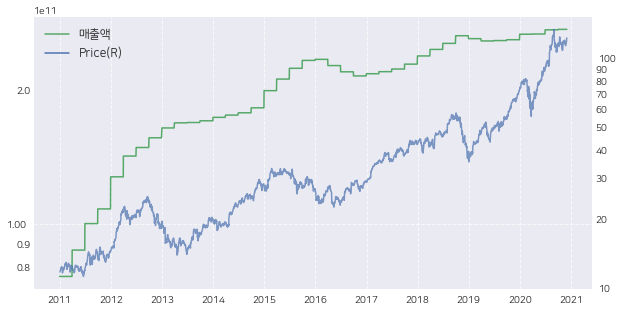

In [35]:
draw_chart(df, left='매출액', right='Price', log=True)

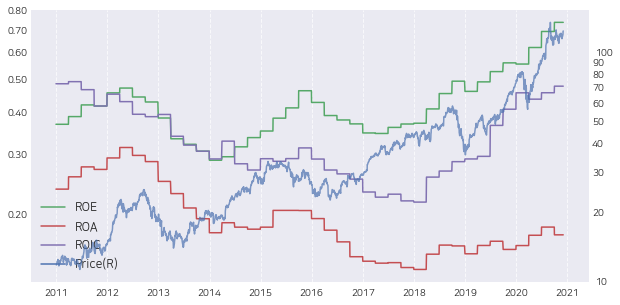

In [36]:
draw_chart(df, left=['ROE', 'ROA', 'ROIC'], right='Price', log=True)

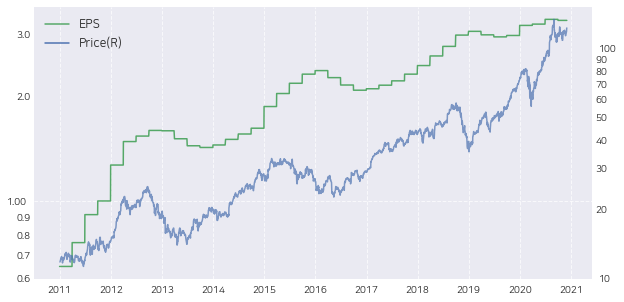

In [37]:
draw_chart(df, left='EPS', right='Price', log=True)

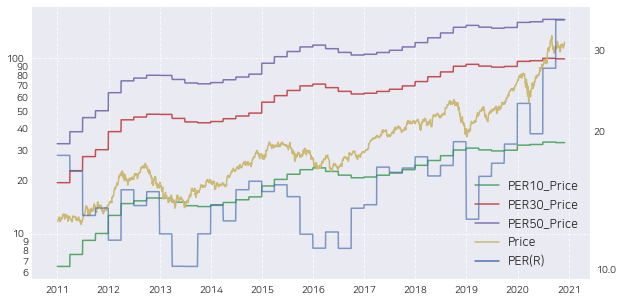

In [38]:
df['PER10_Price'] = df['EPS'] * 10
df['PER30_Price'] = df['EPS'] * 30
df['PER50_Price'] = df['EPS'] * 50
draw_chart(df, left=['PER10_Price','PER30_Price','PER50_Price', 'Price'], right='PER', log=True)

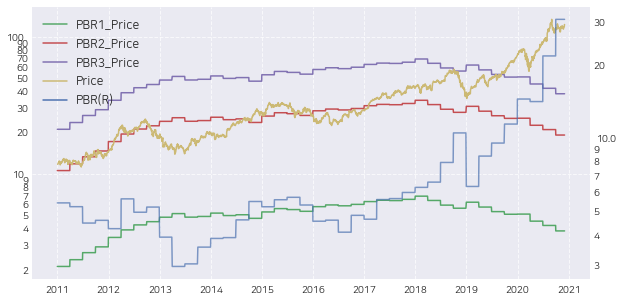

In [39]:
df['BPS'] = df['자본']/df['발행주식수']
df['PBR1_Price'] = df['BPS'] * 1
df['PBR2_Price'] = df['BPS'] * 5
df['PBR3_Price'] = df['BPS'] * 10
draw_chart(df, left=['PBR1_Price','PBR2_Price','PBR3_Price', 'Price'], right='PBR', log=True)

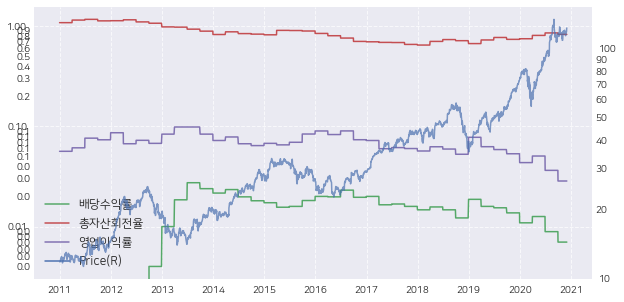

In [40]:
draw_chart(df, left=['배당수익률', '총자산회전율', '영업이익률'], right='Price', log=True)

In [41]:
fn.columns

Index(['매출액', '매출원가', '매출총이익', '판매비와관리비', '영업이익', '당기순이익', 'EPS', 'EBITDA',
       'EBIT', '영업활동현금흐름', '투자활동현금흐름', '재무활동현금흐름', '배당금지급', '유동자산', '비유동자산',
       '자산', '유동부채', '장기차입금', '비유동부채', '부채', '자본', '발행주식수', 'PER', 'PSR',
       'P/FCF', 'PBR', 'EV/Sales', 'EV/EBITDA', 'EV', '시가총액', '당좌비율', '유동비율',
       'Debt/Equity', '부채비율', '총자산회전율', '배당수익률', '영업이익률', '잉여현금흐름', 'ROE',
       'ROA', 'ROIC', '잉여현금흐름'],
      dtype='object', name='id')